# Лабораторная работа 2. Метод ломаных(Пиявского)



Выполнила: Степанова Екатерина K3341 467596

## Выполнение

### Немного теории

**Метод пиявского(ломаных)** - метод нахождения глобального минимума(максимума) липшицевой функции.

Функция $W(x)$ называется Липшицевой, если при любых $u, v ∈ [a, b]$ найдется константа $L>0$, при которой выполняется:

$|W(u) - W(v)| <= L|u-v| $

Иными словами при любых $u, v ∈ [a, b]$, прирост функции между этими точками по модулю будет МЕНЬШЕ, чем прирост самого аргумента по модулю, поноженного на константу.



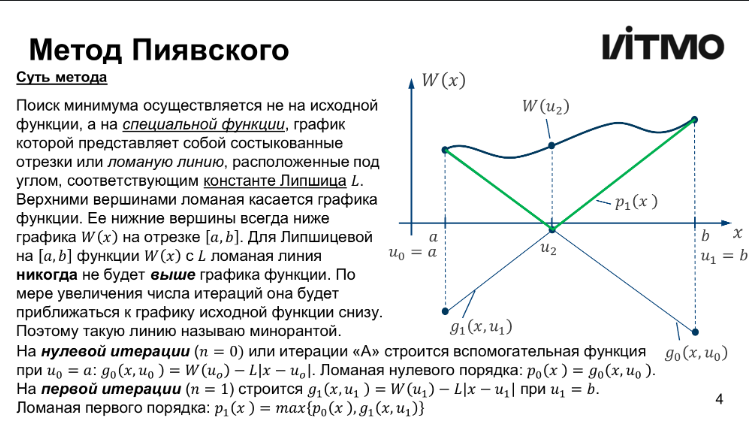

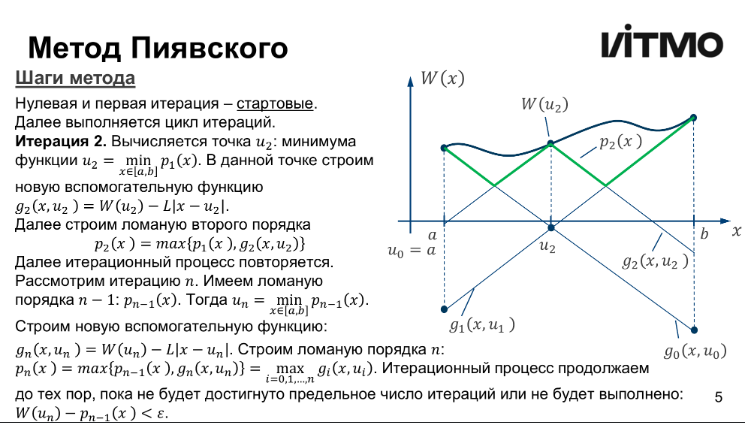

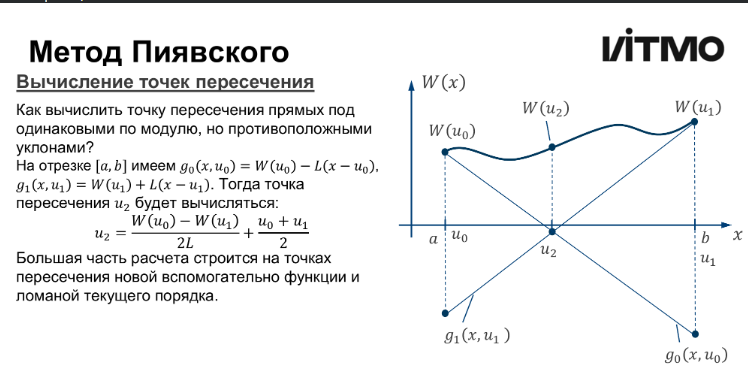

In [19]:
import math, time
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

Функция getattr() в Python получает значение атрибута объекта по его имени, которое передается в виде строки

In [51]:
def parse_function(s):
    # преобразовываем строку в функцию
    # берем правую часть после =
    expr = s.split('=')[1]
    print(expr)
    # заменяем обозначение ^ на ** и убираем пробелы с начала и конца строки
    expr = expr.replace('^', '**').strip()
    # берем все имена из библиотекки math
    env = {k: getattr(math, k) for k in dir(math) if not k.startswith('_')}
    env['abs'] = abs
    return lambda x: eval(expr, {"__builtins__": {}}, {**env, 'x': x})

### Нахождение константы Липшица.



Геометрический смысл этой константы - угловой коэффициент.



По определению, константа Липшица должна удовлетворить неравенству для любых двух точек u, v на отрезке [a, b]


$|W(u) - W(v)| <= L|u-v| $ -> $\frac{|W(u) - W(v)|}{|u-v|} <= L$


т.е. верхняя граница наклона любой секущей(максимально возможная крутизна, с которой функция может расти на этом участке)


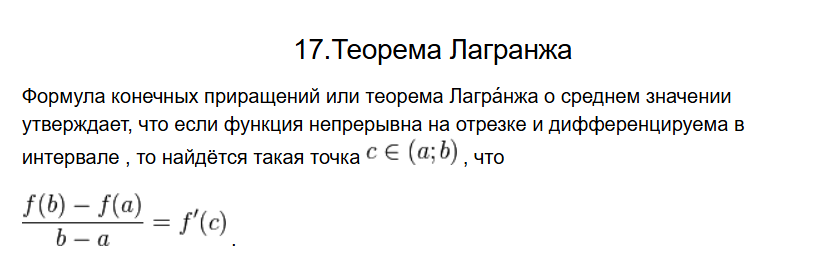

Если функция дифференцируема, то по теореме Лагранжа о среднем значении, наклон секущей между любыми u и v равен производной в некоторой точке c между ними.


$\frac{|W(u) - W(v)|}{|u-v|} = L = W'(c)$

Так как точка c всегда лежит на нашем отрезке, наклон абсолютно любой секущей никогда не сможет превысить самое большое значение производной на этом отрезке.

-> минимально возможная константа L - максимум модуля ее производной

$L = max |W'(x)|$

In [66]:
def find_L(func_str, a, b, n=20001, reserve=1.2):
    W = parse_function(func_str)
    xs = np.linspace(a, b, n)
    ys = np.array([W(x) for x in xs])
    slopes = np.abs(np.diff(ys) / np.diff(xs))
    return reserve * slopes.max()

### Метод ломаных

Идея реализации метода пиявского:

1. Поиск «перспективной» точки $u_{new}$. Внутри каждого интервала между известными точками рассчитываются координаты пересечения ломаной. Находится самая нижняя вершина ломаной с минимальным значением $p_{new}$. Координата $u_{new}$ этой вершины становится кандидатом на новый минимум.

2. Уточнение ломаной. В точке $u_{new}$ вычисляется реальное значение функции $W(u_{new})$.

3. Проверяется разность $Delta = W(u_{new}) - p_{new}$. Если реальное значение функции оказалось близко к прогнозу ломаной (меньше ε), алгоритм завершается.


При поиске глобального максимума мы просто вводим в функцию -W(x), чтобы превратить задачу поиска максимума в задачу поиска минимума.


In [34]:
def piyavsky_method(W, a, b, eps, L, max_iter = 500):
  time_start = time.perf_counter()
  #верхние границы
  u = [a, b]
  Wu = [W(a), W(b)]
  n = 1
  while n < max_iter:
    n+=1
    # нижние вершины
    lower = []
    for i in range(len(u)-1):
      u_cross = (Wu[i]-Wu[i+1])/(2*L) + (u[i] + u[i+1])/2
      p_cross = (Wu[i]+Wu[i+1])/2 - L*(u[i+1] - u[i])/2
      lower.append((p_cross, u_cross, i))
    p_new, u_new, i = min(lower)
    u.insert(i+1, u_new)
    W_n = W(u_new)
    delta = W_n - p_new
    Wu.insert(i+1, W_n)
    if delta < eps:
      break
  k = Wu.index(min(Wu)) # индекс глобального экстремума
  time_end = time.perf_counter()
  return {"u_star": u[k], "W_star": Wu[k], "iterations": n - 1, "delta": delta,
            "time": time_end-time_start, "u": u, "Wu": Wu, "lower": [(x, p) for p, x, _ in lower]}



In [35]:
def plot_result(res, W, a, b, L, title="", show_g=True, max_g=40):
    # метод ломаных для функции W (для максимума сюда передаётся -W)
    xs = np.linspace(a, b, 2000)
    Wv = np.array([W(x) for x in xs])
    u, Wu = res["u"], res["Wu"]

    # основной конструкционный элемент g_i(x, u_i) = W(u_i) - L*|x - u_i|
    G = np.array([[w - L * abs(x - ui) for x in xs] for ui, w in zip(u, Wu)])
    p = G.max(axis=0)                      # ломаная p_n(x)

    plt.figure(figsize=(12, 6))

    if show_g:
        for g in G[:max_g]:
            plt.plot(xs, g, color='gray', lw=0.4, alpha=0.5)
        plt.plot([], [], color='gray', lw=0.6, label=r'$g_i(x,u_i)$')

    plt.plot(xs, Wv, 'b', lw=2, label='$W(x)$')
    plt.plot(xs, p, 'g', lw=1.8, label=r'ломаная $p_n(x)$')
    plt.scatter(u, Wu, s=14, c='k', zorder=3, label=r'верхние вершины $u_i$')
    lx, lp = zip(*res["lower"])
    plt.scatter(lx, lp, s=14, c='orange', zorder=3, label='нижние вершины')
    plt.scatter([res["u_star"]], [res["W_star"]], s=200, c='r', marker='*', zorder=5,
                label=f'минимум: x*={res["u_star"]:.4f}, W*={res["W_star"]:.4f}')

    # ограничиваем ось Y, чтобы длинные хвосты g_i не растягивали график
    lo, hi = Wv.min(), Wv.max()
    plt.ylim(lo - 0.5 * (hi - lo), hi + 0.2 * (hi - lo))
    plt.xlim(a, b)
    plt.grid(alpha=0.3)
    plt.legend(loc='upper right')
    plt.title(title)
    plt.xlabel('x')
    plt.ylabel('W(x)')
    plt.show()


def plot_original_max(W, a, b, x_max, W_max, title=""):
    # исходная W(x) и найденный глобальный максимум
    xs = np.linspace(a, b, 2000)
    plt.figure(figsize=(12, 6))
    plt.plot(xs, [W(x) for x in xs], 'b', lw=2, label='$W(x)$')
    plt.scatter([x_max], [W_max], s=250, c='r', marker='*', zorder=5,
                label=f'максимум: x*={x_max:.4f}, W*={W_max:.4f}')
    plt.xlim(a, b)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.title(title)
    plt.xlabel('x')
    plt.ylabel('W(x)')
    plt.show()

In [64]:
def solve(func_str, a, b, eps, L= None, extremum=None, **kw):
    W = parse_function(func_str)

    if L is None:
      L = find_L(func_str, a, b)
      print(f'Значение L: {L}')
    # если режим не передан, спрашиваем у пользователя
    if extremum is None:
        extremum = input("Что найти? Введите min или max: ").strip().lower()
    if extremum not in ("min", "max"):
        print("Ошибка! Введите только min или max")
        return None

    # метод Пиявского ищет минимум
    # максимум W(x) = минимум -W(x)
    sign = 1 if extremum == "min" else -1
    f = W if extremum == "min" else (lambda x: -W(x))

    res = piyavsky_method(f, a, b, eps, L)
    x_star = res["u_star"]
    W_star = sign * res["W_star"]          # возвращаем знак обратно

    print()
    print(("ГЛОБАЛЬНЫЙ МИНИМУМ") if extremum == "min" else "ГЛОБАЛЬНЫЙ МАКСИМУМ")
    print(f"Функция: {func_str}")
    print(f"Отрезок: [{a}, {b}]")
    print(f"eps = {eps}")
    print(f"L = {L}")
    print(f"x* = {x_star:.6f}")
    print(f"W(x*) = {W_star:.6f}")
    print(f"Число итераций = {res['iterations']}")
    print(f"Время расчёта = {res['time'] * 1000:.2f} мс")

    if extremum == "min":
        plot_result(res, W, a, b, L,
                    title=func_str + " — поиск глобального минимума", **kw)
    else:
        # метод ломаных для -W(x)
        plot_result(res, f, a, b, L,
                    title=func_str + " — метод Пиявского для -W(x)", **kw)
        # исходная W(x) и найденный максимум
        plot_original_max(W, a, b, x_star, W_star,
                          title=func_str + " — найденный глобальный максимум")
    return res

## Функция из методички


 x + sin(3.14159*x)
{'acos': <built-in function acos>, 'acosh': <built-in function acosh>, 'asin': <built-in function asin>, 'asinh': <built-in function asinh>, 'atan': <built-in function atan>, 'atan2': <built-in function atan2>, 'atanh': <built-in function atanh>, 'cbrt': <built-in function cbrt>, 'ceil': <built-in function ceil>, 'comb': <built-in function comb>, 'copysign': <built-in function copysign>, 'cos': <built-in function cos>, 'cosh': <built-in function cosh>, 'degrees': <built-in function degrees>, 'dist': <built-in function dist>, 'e': 2.718281828459045, 'erf': <built-in function erf>, 'erfc': <built-in function erfc>, 'exp': <built-in function exp>, 'exp2': <built-in function exp2>, 'expm1': <built-in function expm1>, 'fabs': <built-in function fabs>, 'factorial': <built-in function factorial>, 'floor': <built-in function floor>, 'fma': <built-in function fma>, 'fmod': <built-in function fmod>, 'frexp': <built-in function frexp>, 'fsum': <built-in function fsum>, 'gamma'

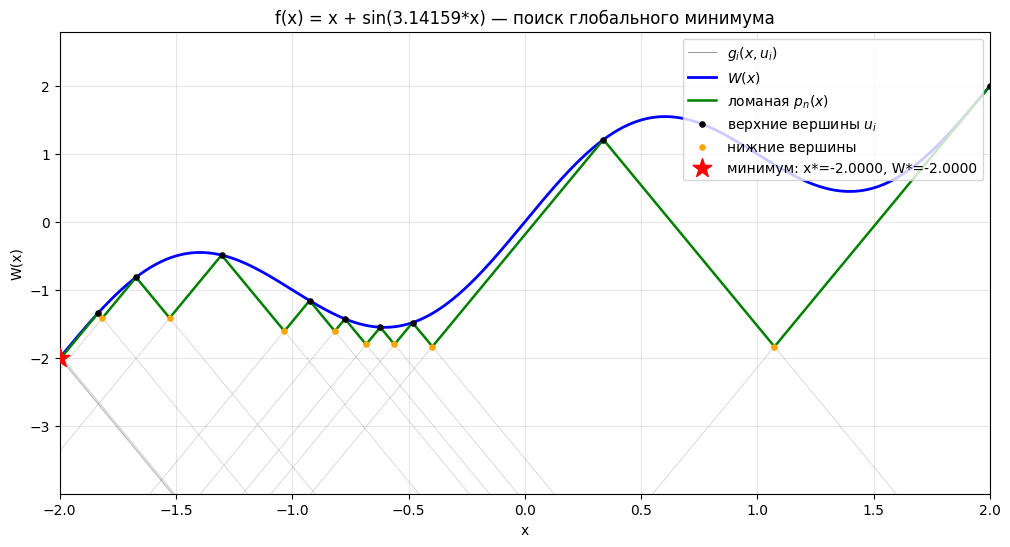

In [62]:
res = solve("f(x) = x + sin(3.14159*x)", -2, 2, 0.01, 4.14159)

 x + sin(3.14159*x)
{'acos': <built-in function acos>, 'acosh': <built-in function acosh>, 'asin': <built-in function asin>, 'asinh': <built-in function asinh>, 'atan': <built-in function atan>, 'atan2': <built-in function atan2>, 'atanh': <built-in function atanh>, 'cbrt': <built-in function cbrt>, 'ceil': <built-in function ceil>, 'comb': <built-in function comb>, 'copysign': <built-in function copysign>, 'cos': <built-in function cos>, 'cosh': <built-in function cosh>, 'degrees': <built-in function degrees>, 'dist': <built-in function dist>, 'e': 2.718281828459045, 'erf': <built-in function erf>, 'erfc': <built-in function erfc>, 'exp': <built-in function exp>, 'exp2': <built-in function exp2>, 'expm1': <built-in function expm1>, 'fabs': <built-in function fabs>, 'factorial': <built-in function factorial>, 'floor': <built-in function floor>, 'fma': <built-in function fma>, 'fmod': <built-in function fmod>, 'frexp': <built-in function frexp>, 'fsum': <built-in function fsum>, 'gamma'

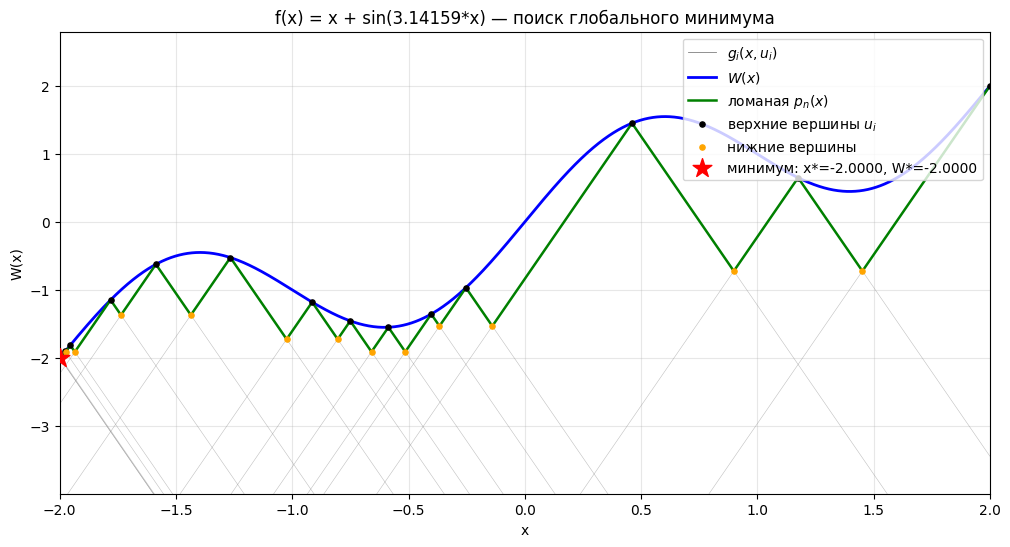

In [65]:
res = solve("f(x) = x + sin(3.14159*x)", -2, 2, 0.01)

## Функция Растригина

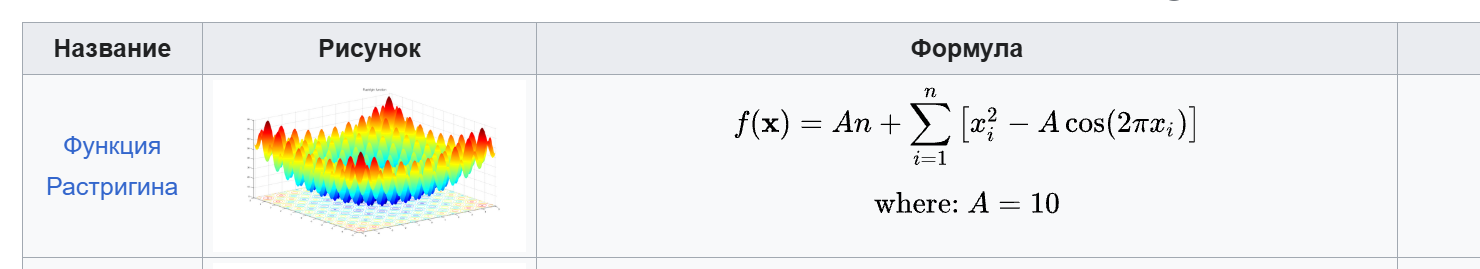

 x**2 - 10*cos(2*pi*x) + 10
{'acos': <built-in function acos>, 'acosh': <built-in function acosh>, 'asin': <built-in function asin>, 'asinh': <built-in function asinh>, 'atan': <built-in function atan>, 'atan2': <built-in function atan2>, 'atanh': <built-in function atanh>, 'cbrt': <built-in function cbrt>, 'ceil': <built-in function ceil>, 'comb': <built-in function comb>, 'copysign': <built-in function copysign>, 'cos': <built-in function cos>, 'cosh': <built-in function cosh>, 'degrees': <built-in function degrees>, 'dist': <built-in function dist>, 'e': 2.718281828459045, 'erf': <built-in function erf>, 'erfc': <built-in function erfc>, 'exp': <built-in function exp>, 'exp2': <built-in function exp2>, 'expm1': <built-in function expm1>, 'fabs': <built-in function fabs>, 'factorial': <built-in function factorial>, 'floor': <built-in function floor>, 'fma': <built-in function fma>, 'fmod': <built-in function fmod>, 'frexp': <built-in function frexp>, 'fsum': <built-in function fsum>,

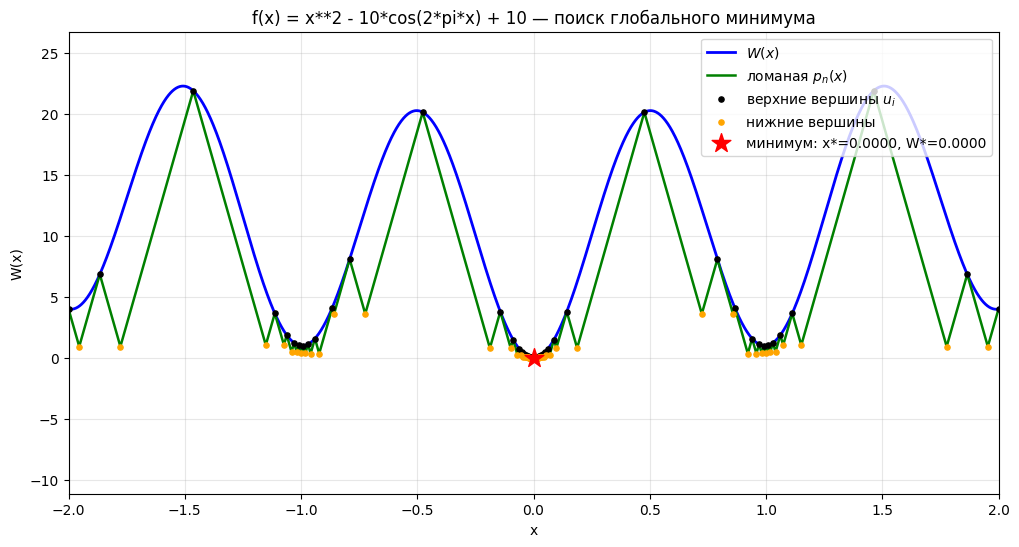

In [57]:
res = solve("f(x) = x**2 - 10*cos(2*pi*x) + 10", -2, 2, 0.01, 66.84, show_g=False)

## Функция Экли

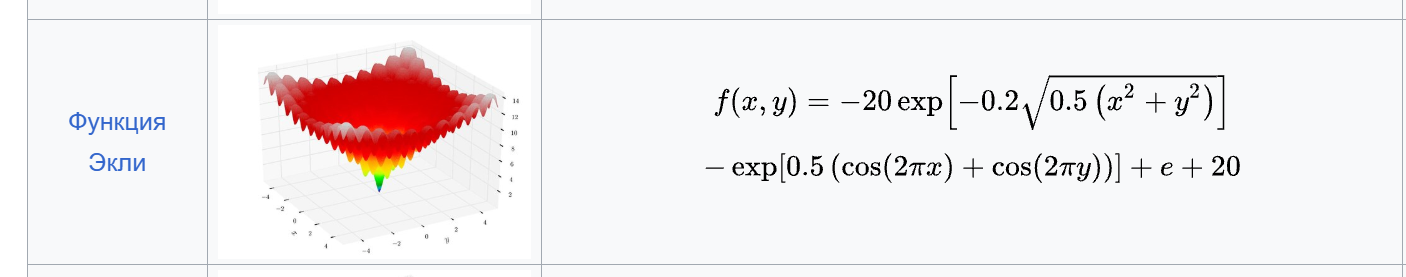

 -20*exp(-0.2*abs(x)) - exp(cos(2*pi*x)) + 20 + e
{'acos': <built-in function acos>, 'acosh': <built-in function acosh>, 'asin': <built-in function asin>, 'asinh': <built-in function asinh>, 'atan': <built-in function atan>, 'atan2': <built-in function atan2>, 'atanh': <built-in function atanh>, 'cbrt': <built-in function cbrt>, 'ceil': <built-in function ceil>, 'comb': <built-in function comb>, 'copysign': <built-in function copysign>, 'cos': <built-in function cos>, 'cosh': <built-in function cosh>, 'degrees': <built-in function degrees>, 'dist': <built-in function dist>, 'e': 2.718281828459045, 'erf': <built-in function erf>, 'erfc': <built-in function erfc>, 'exp': <built-in function exp>, 'exp2': <built-in function exp2>, 'expm1': <built-in function expm1>, 'fabs': <built-in function fabs>, 'factorial': <built-in function factorial>, 'floor': <built-in function floor>, 'fma': <built-in function fma>, 'fmod': <built-in function fmod>, 'frexp': <built-in function frexp>, 'fsum': <bu

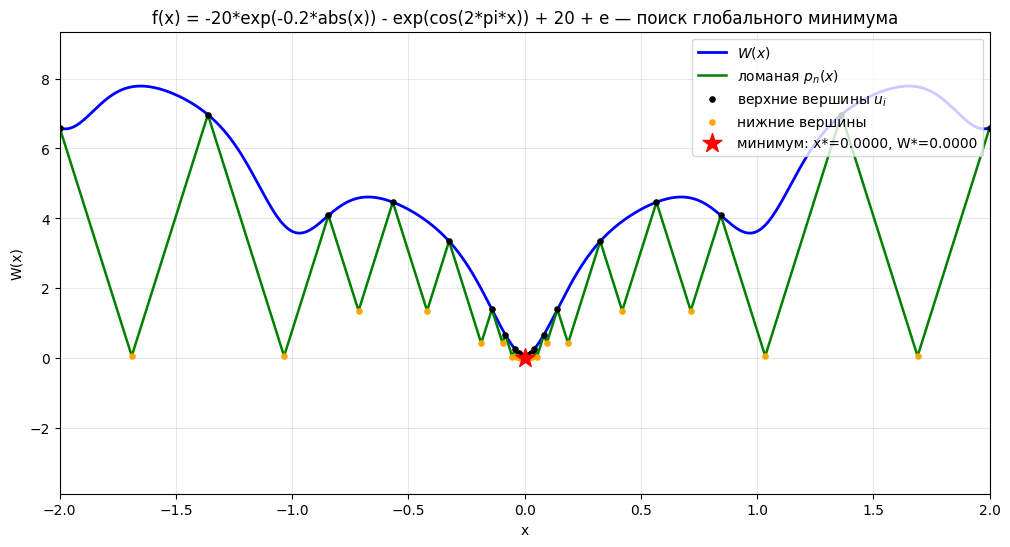

In [53]:
res = solve("f(x) = -20*exp(-0.2*abs(x)) - exp(cos(2*pi*x)) + 20 + e", -2, 2, 0.01, 21.1, show_g=False)